# Token-Efficiency Analysis — GraphQuest
Graph-guided debugging vs a naive whole-file baseline on **cookiecutter bug 2** (`deepseek-chat`).

**Thesis.** Reading the *smallest evidence slice* (function spans located via the Graphify graph) instead of whole files cuts the **context (input) tokens** the model must ingest — the quantity behind the *Lost-in-the-Middle* problem.

Saving for a metric $m$:  $\mathrm{saving}(m) = 1 - \dfrac{m_\text{guided}}{m_\text{baseline}}$.

Figures are the **mean over N repeated runs** (`results/benchmark_runs.json`): output-token noise averages out, while input/char metrics are stable.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
ROOT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p/'results').exists())
mean = json.loads((ROOT/'results/benchmark.json').read_text())
runs = json.loads((ROOT/'results/benchmark_runs.json').read_text())['runs']
debug = json.loads((ROOT/'results/debug_run.json').read_text())
b, g = mean['baseline'], mean['guided']
tot = lambda d: d['input_tokens'] + d['output_tokens']
print('N runs:', mean.get('n'), '| localized  baseline:', b['localized'], 'guided:', g['localized'])

N runs: 5 | localized  baseline: True guided: True


## 1. Mean saving by metric (the headline)

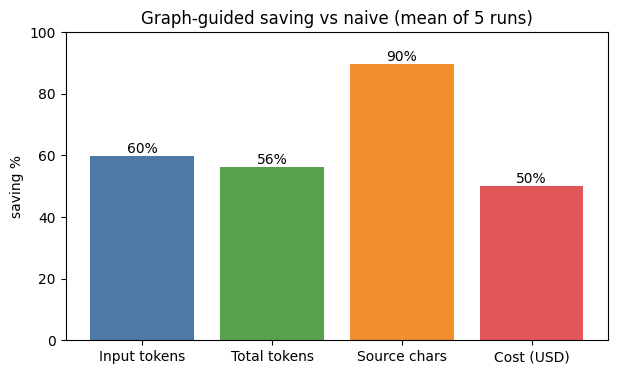

input 59.8% | total 56.3% | chars 89.8%


In [2]:
metrics = [('Input tokens', lambda d: d['input_tokens']), ('Total tokens', tot),
           ('Source chars', lambda d: d['chars_read']), ('Cost (USD)', lambda d: d['cost_usd'])]
labels = [m[0] for m in metrics]
sav = [(1 - f(g)/f(b))*100 if f(b) else 0 for _, f in metrics]
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(labels, sav, color=['#4e79a7','#59a14f','#f28e2b','#e15759'])
for i, s in enumerate(sav): ax.text(i, s+1, f'{s:.0f}%', ha='center')
ax.set_ylabel('saving %'); ax.set_ylim(0, 100)
ax.set_title(f"Graph-guided saving vs naive (mean of {mean.get('n')} runs)")
plt.show()
print('input %.1f%% | total %.1f%% | chars %.1f%%' % (sav[0], sav[1], sav[2]))

## 2. Per-run distribution — why we average
Input tokens are nearly constant (same files vs same spans); the **total** swings because the multi-step agent's *output* length varies. Averaging removes that noise.

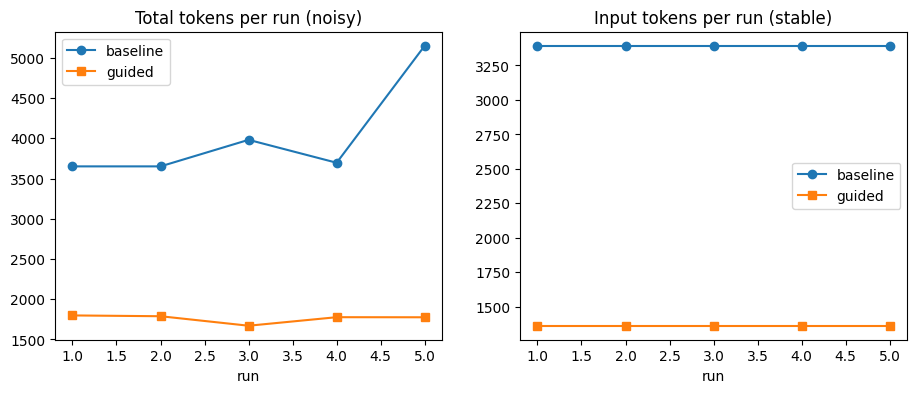

total  guided min/mean/max: 1670 1761 1798
input  guided min/mean/max: 1363 1363 1363


In [3]:
bt = [tot(r['baseline']) for r in runs]; gt = [tot(r['guided']) for r in runs]
bi = [r['baseline']['input_tokens'] for r in runs]; gi = [r['guided']['input_tokens'] for r in runs]
x = range(1, len(runs)+1)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(x, bt, 'o-', label='baseline'); ax[0].plot(x, gt, 's-', label='guided')
ax[0].set_title('Total tokens per run (noisy)'); ax[0].set_xlabel('run'); ax[0].legend()
ax[1].plot(x, bi, 'o-', label='baseline'); ax[1].plot(x, gi, 's-', label='guided')
ax[1].set_title('Input tokens per run (stable)'); ax[1].set_xlabel('run'); ax[1].legend()
plt.show()
print('total  guided min/mean/max:', min(gt), round(sum(gt)/len(gt)), max(gt))
print('input  guided min/mean/max:', min(gi), round(sum(gi)/len(gi)), max(gi))

## 3. Agent per-step token usage
The graph-guided agent reads the graph first and source last: `hypothesize` (edge summaries) -> `validate` (suspect + test spans) -> `fix`.

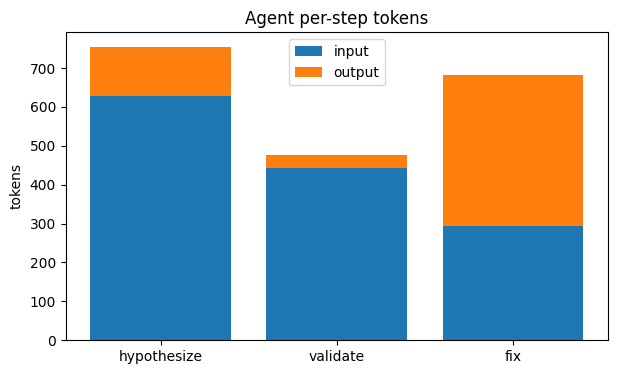

root cause: The test expects `find_hook` to return a list (accessing index `[0]`), but the function returns a single string path or `None`.


In [4]:
tl = debug.get('token_log', [])
steps = ['hypothesize','validate','fix'][:len(tl)]
ins = [t[0] for t in tl]; outs = [t[1] for t in tl]
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(steps, ins, label='input'); ax.bar(steps, outs, bottom=ins, label='output')
ax.set_ylabel('tokens'); ax.set_title('Agent per-step tokens'); ax.legend(); plt.show()
print('root cause:', debug['root_cause'][:160])

## 4. Sensitivity — saving grows with codebase size
The baseline reads whole files, so its context grows with file size; the guided agent reads a fixed-size function span. As the unfamiliar codebase gets larger, the char saving approaches 100%.

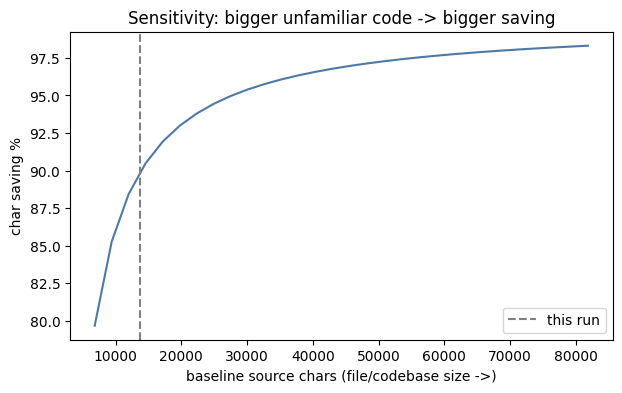

In [5]:
mult = np.linspace(0.5, 6, 30)
sav = [(1 - g['chars_read']/(b['chars_read']*m))*100 for m in mult]
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(b['chars_read']*mult, sav, color='#4e79a7')
ax.axvline(b['chars_read'], ls='--', color='gray', label='this run')
ax.set_xlabel('baseline source chars (file/codebase size ->)'); ax.set_ylabel('char saving %')
ax.set_title('Sensitivity: bigger unfamiliar code -> bigger saving'); ax.legend(); plt.show()

## 5. Amortization across queries
The deterministic Graphify graph costs **zero tokens** to build, so the per-query saving is pure gain with nothing to amortize (the semantic layer is optional/one-time).

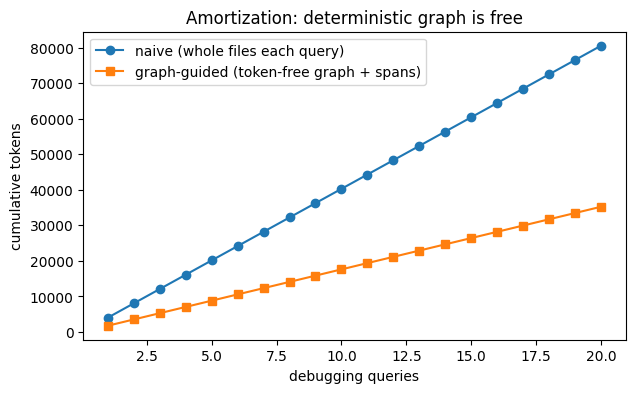

In [6]:
N = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(N, N*tot(b), 'o-', label='naive (whole files each query)')
ax.plot(N, N*tot(g), 's-', label='graph-guided (token-free graph + spans)')
ax.set_xlabel('debugging queries'); ax.set_ylabel('cumulative tokens')
ax.set_title('Amortization: deterministic graph is free'); ax.legend(); plt.show()

## Conclusion
Graph-guided debugging cuts **input/context tokens by ~60%** and **source chars by ~90%** (stable, retrieval-controlled), localizing the same bug. The multi-step agent spends more *output* tokens, so the total saving is smaller and noisier — reported as a mean. The advantage **grows with codebase size** and amortizes for free because the deterministic graph costs no tokens. This is the Graphify thesis, measured.